<a href="https://colab.research.google.com/github/toryor31oct/group15-Fun-Rai-Kwam-plod-Phai/blob/Tang-oh/graph3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# โหลดไฟล์ข้อมูลการเคลม

In [59]:
import pandas as pd

# (มีข้อมูลลูกค้าและกรมธรรม์อยู่แล้ว)
df_claims = pd.read_csv("claims_system.csv")

# ตั้งค่าฟอร์แมตตัวเลข
pd.options.display.float_format = "{:,.2f}".format


# ตั้งคำถามเกี่ยวกับธุรกิจแล้วตอบด้วย pandas
คำถามที่ 1: ประกันแต่ละประเภทมี "ยอดรวมเงินจ่ายสุทธิ" และ "ยอดขอเบิกเฉลี่ย" เท่าใด

คำถามที่ 2: ภาพรวมสถานะการอนุมัติ (Approved vs Rejected) มีจำนวนกี่เคส และจ่ายเงินสุทธิรวมเท่าใด

คำถามที่ 3: เมื่อจำแนกตามประเภทประกัน มีจำนวนเคสที่ผ่านอนุมัติและถูกปฏิเสธอย่างไรบ้าง?

คำถามที่ 4: ผู้รับประโยชน์กลุ่มไหน (บิดา, มารดา, บุตร ฯลฯ) มีจำนวนเคสมากสุด พร้อมยอดจ่ายสูงสุดและค่าเฉลี่ย?

In [60]:
# คำถามที่ 3: เมื่อจำแนกตามประเภทประกัน มีจำนวนเคสที่ผ่านอนุมัติและถูกปฏิเสธอย่างไรบ้าง?

# part1 จำนวนเคสที่ผ่านอนุมัติและถูกปฏิเสธ
q3_df = (df_claims.groupby(["insurance_type", "payment_status"]).agg(
         total_cases = ("claim_id", "count"),
         total_payout = ("net_payout", "sum"),).sort_values(by=["insurance_type", "payment_status"], ascending=False))
print("=== จำนวนเคสและยอดจ่ายรวม ( Completed = ผ่าน | Cancelled = ไม่ผ่าน ) ===")
display(q3_df)

# part2 เหตุผลที่ไม่ผ่าน พร้อมส่วนต่างเงินที่ยื่นเกินวงเงิน
df_rejected = df_claims[df_claims["payment_status"] == "Cancelled"].copy()
df_rejected["excess_amount"] = (df_rejected["claim_amount"] - df_rejected["coverage_limit"])

q3_detail_df = (df_rejected.groupby(["insurance_type", "claim_detail"]).agg(
                rejected_cases = ("claim_id", "count"),
                avg_claim_amount = ("claim_amount", "mean"),
                avg_coverage_limit = ("coverage_limit", "mean"),
                avg_axcess_amount = ("excess_amount", "mean"),).sort_values(by="rejected_cases", ascending=False))

print("\n=== เหตุผลที่ไม่ผ่าน และยอดเงินที่ยื่นเกินวงเงิน ==="
)
display(q3_detail_df)

=== จำนวนเคสและยอดจ่ายรวม ( Completed = ผ่าน | Cancelled = ไม่ผ่าน ) ===


total_cases   total_payout
insurance_type   payment_status                            
ประกันโรคร้ายแรง Paid                     70  81,972,000.00
ประกันอุบัติเหตุ Paid                     68  19,886,779.63
                 Cancelled                 7           0.00
ประกันสุขภาพ     Paid                     63  26,216,579.78
                 Cancelled                17           0.00
ประกันชีวิต      Paid                     75 137,857,500.00


=== เหตุผลที่ไม่ผ่าน และยอดเงินที่ยื่นเกินวงเงิน ===


rejected_cases  \
insurance_type   claim_detail                                                    
ประกันสุขภาพ     ผ่าตัดไส้ติ่งอักเสบฉุกเฉิน                                  6   
                 เข้ารับการรักษาผู้ป่วยใน (IPD) โรคไข้หวัดใหญ่               6   
                 เข้ารับการรักษาผู้ป่วยนอก (OPD) ลำไส้อักเสบ                 5   
ประกันอุบัติเหตุ เข้ารักษาฉุกเฉินจากลื่นล้มหกล้ม                             4   
                 กระดูกข้อเท้าแตกหักจากการเล่นกีฬา                           3   

                                                                avg_claim_amount  \
insurance_type   claim_detail                                                      
ประกันสุขภาพ     ผ่าตัดไส้ติ่งอักเสบฉุกเฉิน                           689,911.16   
                 เข้ารับการรักษาผู้ป่วยใน (IPD) โรคไข้หวัดใหญ่        712,611.01   
                 เข้ารับการรักษาผู้ป่วยนอก (OPD) ลำไส้อักเสบ          538,794.15   
ประกันอุบัติเหตุ เข้ารักษาฉุกเฉินจากลื่นล้มหกล้ม                      537,886.95   
                 กระดูกข้อเท้าแตกหักจากการเล่นกีฬา                    719,952.44   

                                                                avg_coverage_limit  \
insurance_type   claim_detail                                                        
ประกันสุขภาพ     ผ่าตัดไส้ติ่งอักเสบฉุกเฉิน                             675,000.00   
                 เข้ารับการรักษาผู้ป่วยใน (IPD) โรคไข้หวัดใหญ่          650,000.00   
                 เข้ารับการรักษาผู้ป่วยนอก (OPD) ลำไส้อักเสบ            500,000.00   
ประกันอุบัติเหตุ เข้ารักษาฉุกเฉินจากลื่นล้มหกล้ม                        512,500.00   
                 กระดูกข้อเท้าแตกหักจากการเล่นกีฬา                      683,333.33   

                                                                avg_axcess_amount  
insurance_type   claim_detail                                                      
ประกันสุขภาพ     ผ่าตัดไส้ติ่งอักเสบฉุกเฉิน                             14,911.16  
                 เข้ารับการรักษาผู้ป่วยใน (IPD) โรคไข้หวัดใหญ่          62,611.01  
                 เข้ารับการรักษาผู้ป่วยนอก (OPD) ลำไส้อักเสบ            38,794.15  
ประกันอุบัติเหตุ เข้ารักษาฉุกเฉินจากลื่นล้มหกล้ม                        25,386.96  
                 กระดูกข้อเท้าแตกหักจากการเล่นกีฬา                      36,619.11

In [61]:
# แปลงชื่อประเภทประกันเป็นภาษาอังกฤษ
type_map = {
    'ประกันสุขภาพ': 'Health',
    'ประกันอุบัติเหตุ': 'Accident',
    'ประกันชีวิต': 'Life',
    'ประกันรถยนต์': 'Auto',
}

df_claims['insurance_type_en'] = df_claims['insurance_type'].map(type_map)

In [62]:
import matplotlib.pyplot as plt

<Figure size 900x500 with 0 Axes>

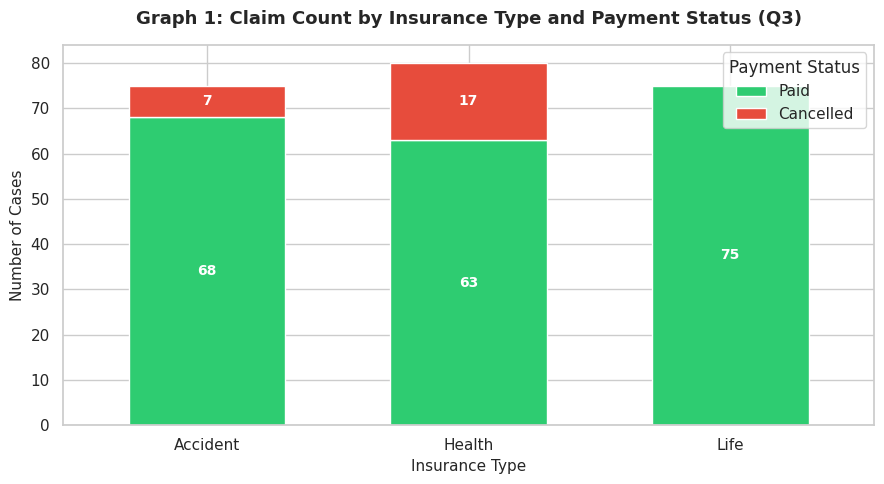

In [63]:
# กราฟที่ 1: Stacked Bar Chart - จำนวน Paid / Cancelled แยกตามประเภทประกัน (กราฟหลัก Q3)

plt.figure(figsize=(9, 5))
status_counts = (
    df_claims.groupby(['insurance_type_en', 'payment_status'])
    .size()
    .unstack(fill_value=0)
)
cols = [c for c in ['Paid', 'Cancelled'] if c in status_counts.columns]
status_counts = status_counts[cols]

ax1 = status_counts.plot(
    kind='bar',
    stacked=True,
    color=['#2ecc71', '#e74c3c'],
    figsize=(9, 5),
    width=0.6,
)
plt.title(
    'Graph 1: Claim Count by Insurance Type and Payment Status (Q3)',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Insurance Type', fontsize=11)
plt.ylabel('Number of Cases', fontsize=11)
plt.legend(title='Payment Status', frameon=True)
plt.xticks(rotation=0)

# แสดงตัวเลขจำนวนเคสในแต่ละส่วนของแท่ง
for c in ax1.containers:
  for p in c:
    height = p.get_height()
    if height > 0:
      ax1.annotate(
          f'{int(height)}',
          (p.get_x() + p.get_width() / 2., p.get_y() + height / 2.),
          ha='center',
          va='center',
          color='white',
          fontweight='bold',
          fontsize=10,
      )

plt.tight_layout()
plt.show()

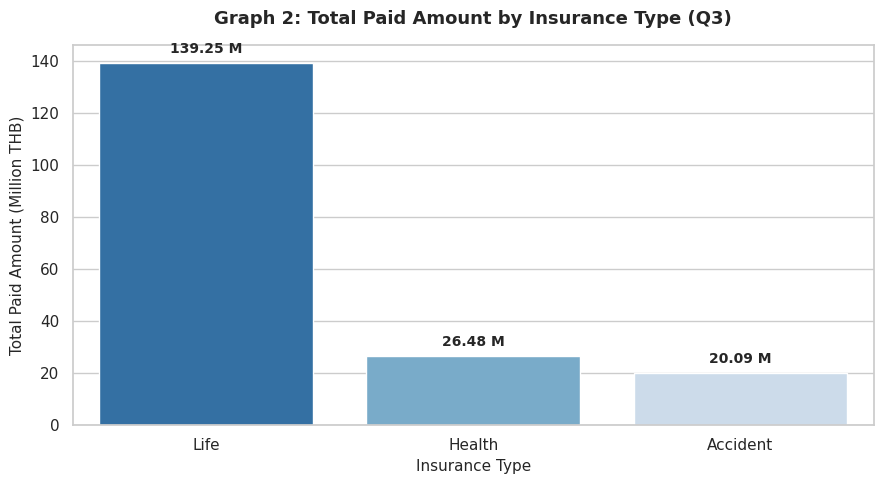

In [64]:
# กราฟที่ 2: Bar Chart - ยอดจ่ายจริงรวม (Paid Amount) แยกตามประเภทประกัน
plt.figure(figsize=(9, 5))
payout_summary = (
    df_claims.groupby('insurance_type_en')['paid_amount'].sum().reset_index()
)
payout_summary['paid_amount_m'] = payout_summary['paid_amount'] / 1e6
payout_summary = payout_summary.sort_values(
    by='paid_amount_m', ascending=False
)

ax2 = sns.barplot(
    data=payout_summary,
    x='insurance_type_en',
    y='paid_amount_m',
    hue='insurance_type_en',
    palette='Blues_r',
)
plt.title(
    'Graph 2: Total Paid Amount by Insurance Type (Q3)',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Insurance Type', fontsize=11)
plt.ylabel('Total Paid Amount (Million THB)', fontsize=11)

# แสดงตัวเลขยอดเงิน (ล้านบาท) บนยอดแท่ง
for p in ax2.patches:
  val = p.get_height()
  ax2.annotate(
      f'{val:,.2f} M',
      (p.get_x() + p.get_width() / 2., val),
      ha='center',
      va='bottom',
      fontsize=10,
      fontweight='bold',
      xytext=(0, 5),
      textcoords='offset points',
  )

plt.tight_layout()
plt.show()


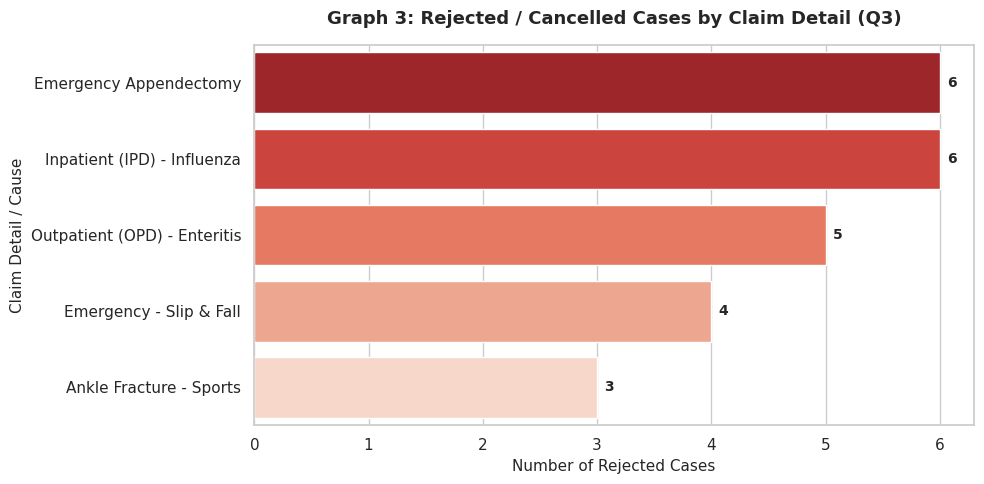

In [65]:
# กราฟที่ 3: Horizontal Bar Chart - จำนวนเคสที่ถูกปฏิเสธ (Cancelled) แยกตามสาเหตุ/รายละเอียด
rejected_df = df_claims[df_claims['payment_status'] == 'Cancelled'].copy()

detail_map_en = {
    'เข้ารับการรักษาผู้ป่วยใน (IPD) โรคไข้หวัดใหญ่': 'Inpatient (IPD) - Influenza',
    'ผ่าตัดไส้ติ่งอักเสบฉุกเฉิน': 'Emergency Appendectomy',
    'เข้ารับการรักษาผู้ป่วยนอก (OPD) ลำไส้อักเสบ': 'Outpatient (OPD) - Enteritis',
    'เข้ารักษาฉุกเฉินจากลื่นล้มหกล้ม': 'Emergency - Slip & Fall',
    'กระดูกข้อเท้าแตกหักจากการเล่นกีฬา': 'Ankle Fracture - Sports',
}
rejected_df['claim_detail_en'] = rejected_df['claim_detail'].map(
    detail_map_en
).fillna(rejected_df['claim_detail'])

detail_counts = rejected_df['claim_detail_en'].value_counts().reset_index()
detail_counts.columns = ['claim_detail_en', 'count']

plt.figure(figsize=(10, 5))
ax3 = sns.barplot(
    data=detail_counts,
    y='claim_detail_en',
    x='count',
    hue='claim_detail_en',
    palette='Reds_r',
)
plt.title(
    'Graph 3: Rejected / Cancelled Cases by Claim Detail (Q3)',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Number of Rejected Cases', fontsize=11)
plt.ylabel('Claim Detail / Cause', fontsize=11)

# แสดงตัวเลขจำนวนเคสตรงปลายแท่งกราฟ
for p in ax3.patches:
  val = p.get_width()
  ax3.annotate(
      f'{int(val)}',
      (val, p.get_y() + p.get_height() / 2.),
      ha='left',
      va='center',
      fontsize=10,
      fontweight='bold',
      xytext=(5, 0),
      textcoords='offset points',
  )

plt.tight_layout()
plt.show()